<a href="https://colab.research.google.com/github/RiderTheSpeedLover/Jio_Institute/blob/Regression/Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset (replace 'dataset.csv' with your file path)
df = pd.read_csv('MRM.csv')

# Display descriptive statistics
descriptive_stats = df.describe(include='all')
print("Descriptive Statistics:\n", descriptive_stats)

# Handling missing values
df = df.dropna()  # Drop rows with missing values (can be customized)

# Separating numerical and categorical variables
numerical_vars = df.select_dtypes(include=['int64', 'float64']).columns
categorical_vars = df.select_dtypes(include=['object']).columns

# Encoding categorical variables using OneHotEncoding
# Removing the 'sparse' argument as it's not supported in older versions
ct = ColumnTransformer([
    ('encoder', OneHotEncoder(drop='first'), categorical_vars) # Removing sparse=False
], remainder='passthrough')

# Splitting data into features and target
X = df.drop(columns=['price'])  # Independent variables
y = df['price']  # Dependent variable

# Transforming features with encoding
X_transformed = ct.fit_transform(X)

# Splitting the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.2, random_state=42)

# Running a regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predicting on test data
y_pred = model.predict(X_test)

# Evaluating the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared Score:", r2)

# Running OLS regression for detailed statistics
X_ols = sm.add_constant(X_transformed)  # Adding a constant for intercept
ols_model = sm.OLS(y, X_ols).fit()
print(ols_model.summary())

Descriptive Statistics:
                 index     dateCrawled         name  seller offerType  \
count   371527.000000          371527       371527  371527    371527   
unique            NaN           15622       233519       2         2   
top               NaN  05/03/16 14:25  Ford_Fiesta  privat   Angebot   
freq              NaN              68          657  371524    371515   
mean    185763.617161             NaN          NaN     NaN       NaN   
std     107251.160306             NaN          NaN     NaN       NaN   
min          0.000000             NaN          NaN     NaN       NaN   
25%      92881.500000             NaN          NaN     NaN       NaN   
50%     185764.000000             NaN          NaN     NaN       NaN   
75%     278645.500000             NaN          NaN     NaN       NaN   
max     371527.000000             NaN          NaN     NaN       NaN   

       vehicleType  yearOfRegistration  gearbox        powerPS   model  \
count       333658       371527.0000

<ipython-input-2-59c246cd9068>:55: SparseEfficiencyWarning: Comparing a sparse matrix with 0 using == is inefficient, try using != instead.
  X_ols = sm.add_constant(X_transformed)  # Adding a constant for intercept


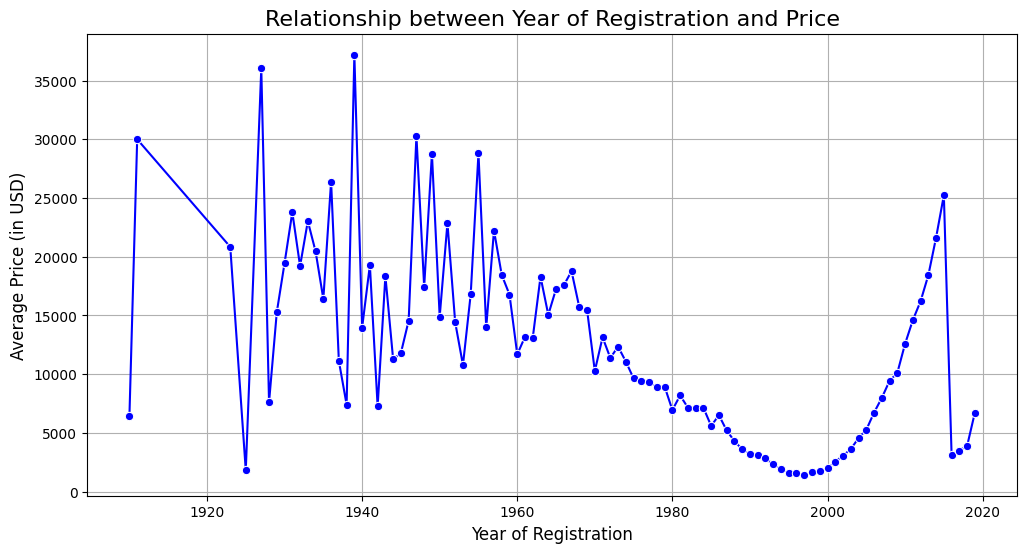

The trend shows a mixed pattern. Cars registered in recent years may have higher prices due to newer technology and better features.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset (replace 'dataset.csv' with your actual file)
df = pd.read_csv('MRM.csv')

# Handle missing values by removing rows with missing data
df = df.dropna(subset=['yearOfRegistration', 'price'])

# Filter out unrealistic values for 'price' and 'yearOfRegistration'
df = df[(df['price'] > 100) & (df['price'] < 100000)]  # Filter price range
df = df[(df['yearOfRegistration'] >= 1900) & (df['yearOfRegistration'] <= 2024)]  # Filter valid years

# Aggregate data to find mean price per year of registration
year_price = df.groupby('yearOfRegistration')['price'].mean().reset_index()

# Plotting the relationship between yearOfRegistration and price
plt.figure(figsize=(12, 6))
sns.lineplot(data=year_price, x='yearOfRegistration', y='price', marker='o', color='b')
plt.title('Relationship between Year of Registration and Price', fontsize=16)
plt.xlabel('Year of Registration', fontsize=12)
plt.ylabel('Average Price (in USD)', fontsize=12)
plt.grid(True)
plt.show()

# Interpretation
if year_price['price'].is_monotonic_decreasing:
    print("There is a clear decreasing trend in car prices as the year of registration increases. This may indicate depreciation or that older cars are less valued.")
else:
    print("The trend shows a mixed pattern. Cars registered in recent years may have higher prices due to newer technology and better features.")


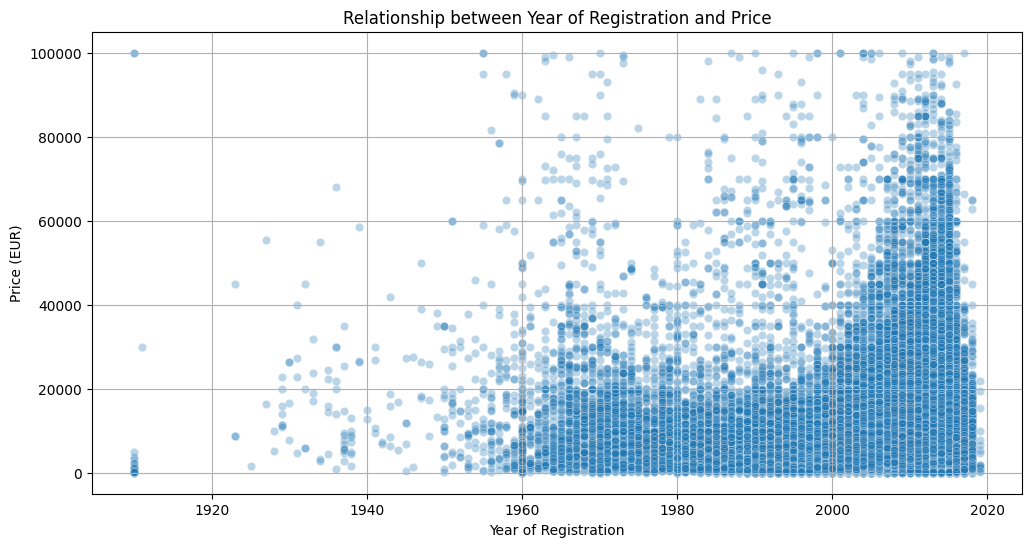

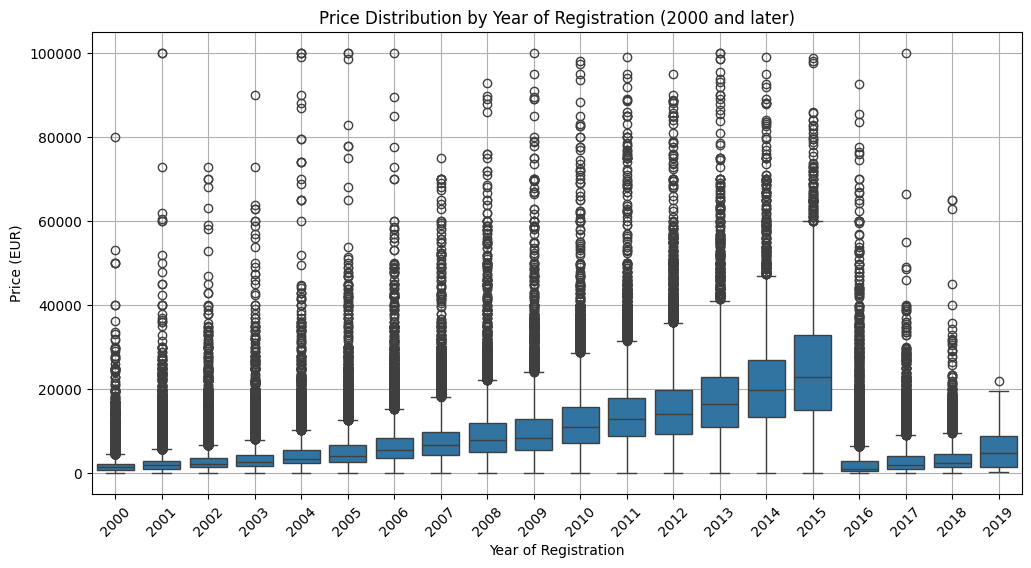

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset (Replace 'your_file_path.csv' with the actual file path)
data = pd.read_csv('MRM.csv')

# Data cleaning: Filter invalid values for yearOfRegistration and price
valid_data = data[(data['yearOfRegistration'] >= 1900) & (data['yearOfRegistration'] <= 2023)]
valid_data = valid_data[(valid_data['price'] > 100) & (valid_data['price'] < 100000)]

# Plot the relationship using a scatter plot
plt.figure(figsize=(12, 6))
sns.scatterplot(x='yearOfRegistration', y='price', data=valid_data, alpha=0.3)
plt.title('Relationship between Year of Registration and Price')
plt.xlabel('Year of Registration')
plt.ylabel('Price (EUR)')
plt.grid(True)
plt.show()

# Optional: Boxplot to visualize price distribution for recent years
recent_years = valid_data[valid_data['yearOfRegistration'] >= 2000]
plt.figure(figsize=(12, 6))
sns.boxplot(x='yearOfRegistration', y='price', data=recent_years)
plt.xticks(rotation=45)
plt.title('Price Distribution by Year of Registration (2000 and later)')
plt.xlabel('Year of Registration')
plt.ylabel('Price (EUR)')
plt.grid(True)
plt.show()


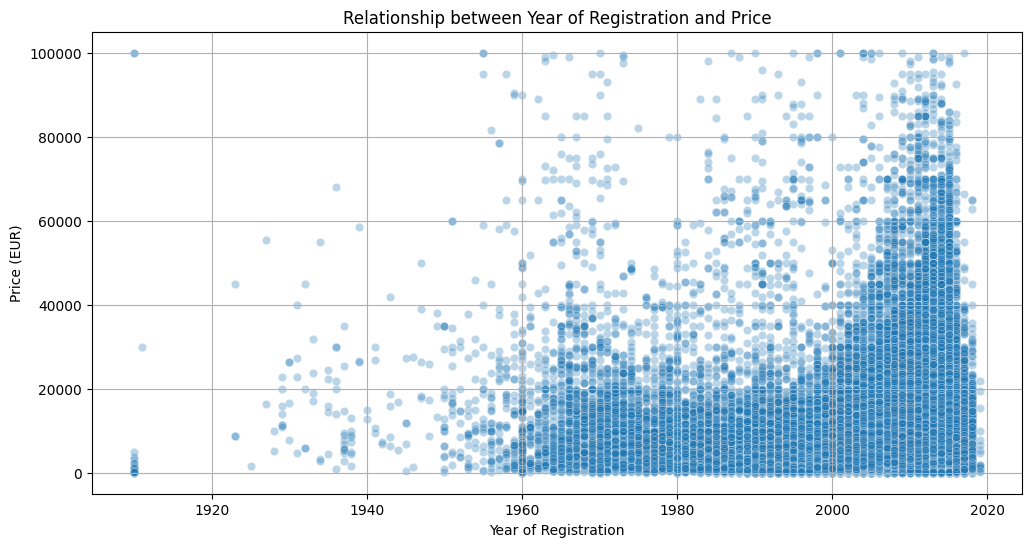

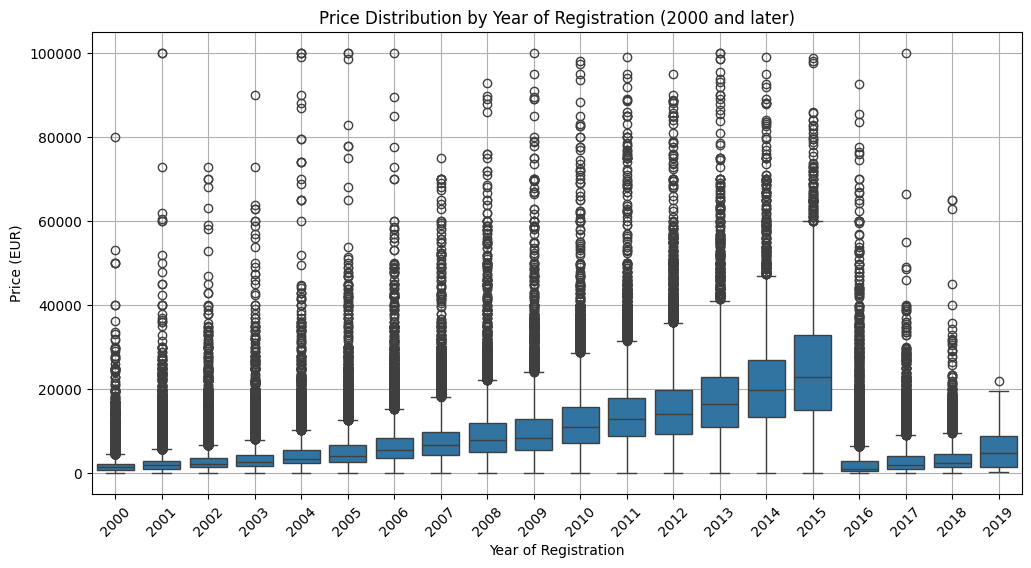

<ipython-input-2-eefcd3d88827>:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fuel_price.index, y=fuel_price.values, palette='viridis')


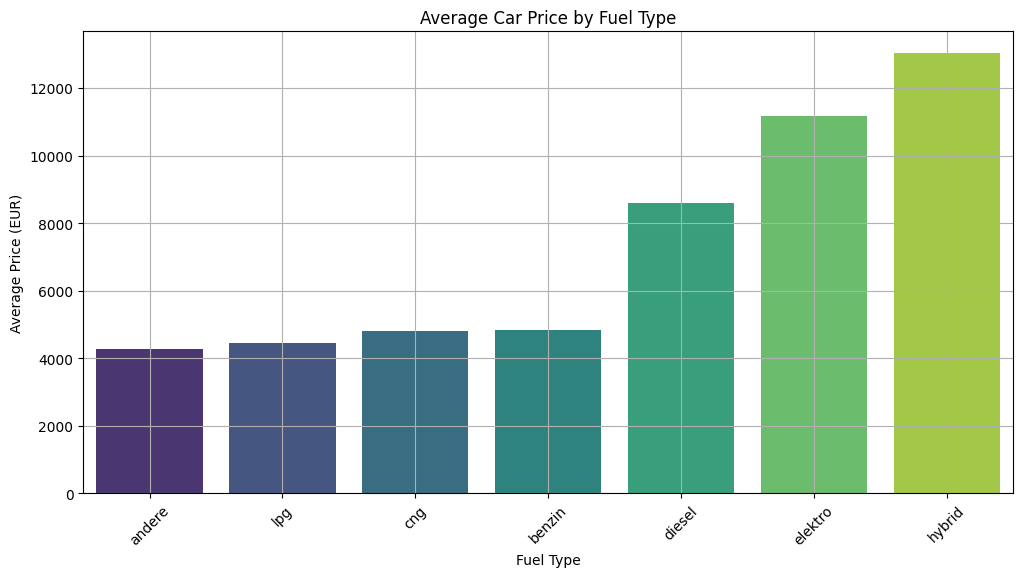

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset (Replace 'your_file_path.csv' with the actual file path)
data = pd.read_csv('/content/MRM.csv')

# Data cleaning: Filter invalid values for yearOfRegistration and price
valid_data = data[(data['yearOfRegistration'] >= 1900) & (data['yearOfRegistration'] <= 2023)]
valid_data = valid_data[(valid_data['price'] > 100) & (valid_data['price'] < 100000)]

# Plot the relationship using a scatter plot
plt.figure(figsize=(12, 6))
sns.scatterplot(x='yearOfRegistration', y='price', data=valid_data, alpha=0.3)
plt.title('Relationship between Year of Registration and Price')
plt.xlabel('Year of Registration')
plt.ylabel('Price (EUR)')
plt.grid(True)
plt.show()

# Optional: Boxplot to visualize price distribution for recent years
recent_years = valid_data[valid_data['yearOfRegistration'] >= 2000]
plt.figure(figsize=(12, 6))
sns.boxplot(x='yearOfRegistration', y='price', data=recent_years)
plt.xticks(rotation=45)
plt.title('Price Distribution by Year of Registration (2000 and later)')
plt.xlabel('Year of Registration')
plt.ylabel('Price (EUR)')
plt.grid(True)
plt.show()

# Analyze how fuelType impacts car prices using a bar chart
plt.figure(figsize=(12, 6))
fuel_price = valid_data.groupby('fuelType')['price'].mean().sort_values()
sns.barplot(x=fuel_price.index, y=fuel_price.values, palette='viridis')
plt.title('Average Car Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Average Price (EUR)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


Regression Coefficients:
Year of Registration: 223.24270958113544
Kilometer: -0.07191508874751691
Intercept: -432378.30633385526

Model Evaluation:
Mean Squared Error: 43955222.33784777
R-squared: 0.2317059909546325


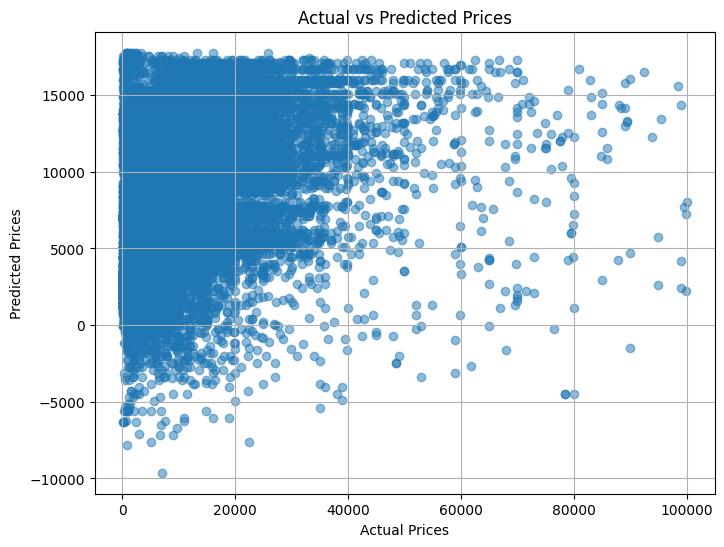

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset (Replace 'your_file_path.csv' with the actual file path)
data = pd.read_csv('/content/MRM.csv')

# Data cleaning: Filter invalid values for yearOfRegistration and price
valid_data = data[(data['yearOfRegistration'] >= 1900) & (data['yearOfRegistration'] <= 2023)]
valid_data = valid_data[(valid_data['price'] > 100) & (valid_data['price'] < 100000)]

# Select features and target variable for regression
X = valid_data[['yearOfRegistration', 'kilometer']]
y = valid_data['price']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build the regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print regression coefficients and model evaluation metrics
print("Regression Coefficients:")
print(f"Year of Registration: {model.coef_[0]}")
print(f"Kilometer: {model.coef_[1]}")
print(f"Intercept: {model.intercept_}")
print("\nModel Evaluation:")
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

# Plot actual vs predicted prices
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.title('Actual vs Predicted Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.grid(True)
plt.show()


                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.231
Model:                            OLS   Adj. R-squared:                  0.231
Method:                 Least Squares   F-statistic:                 5.363e+04
Date:                Mon, 30 Dec 2024   Prob (F-statistic):               0.00
Time:                        16:47:10   Log-Likelihood:            -3.6441e+06
No. Observations:              356648   AIC:                         7.288e+06
Df Residuals:                  356645   BIC:                         7.288e+06
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const              -4.345e+05   3040

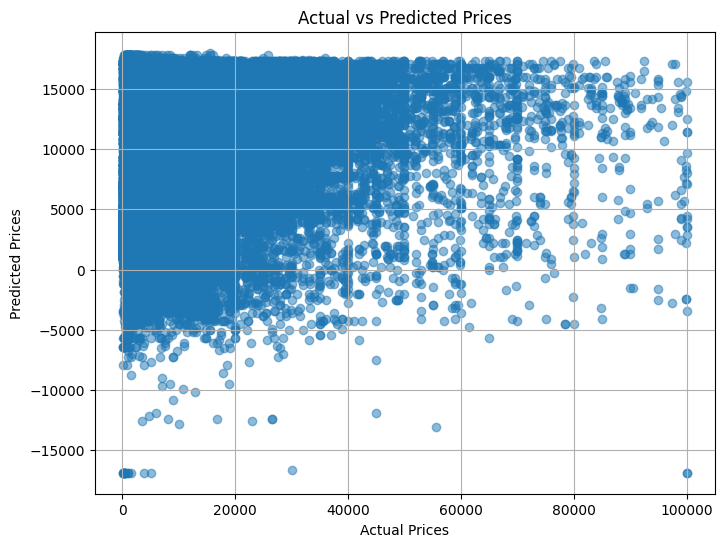

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm

# Load the dataset (Replace 'your_file_path.csv' with the actual file path)
data = pd.read_csv('/content/MRM.csv')

# Data cleaning: Filter invalid values for yearOfRegistration and price
valid_data = data[(data['yearOfRegistration'] >= 1900) & (data['yearOfRegistration'] <= 2023)]
valid_data = valid_data[(valid_data['price'] > 100) & (valid_data['price'] < 100000)]

# Select features and target variable for regression
X = valid_data[['yearOfRegistration', 'kilometer']]
y = valid_data['price']

# Add a constant to the predictors for statsmodels
X = sm.add_constant(X)

# Build the regression model using statsmodels
model = sm.OLS(y, X).fit()

# Print the regression summary
print(model.summary())

# Plot actual vs predicted prices
plt.figure(figsize=(8, 6))
y_pred = model.predict(X)
plt.scatter(y, y_pred, alpha=0.5)
plt.title('Actual vs Predicted Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.grid(True)
plt.show()


Seller Type Summary:
                price                                                    \
               count         mean          std     min     25%     50%   
seller                                                                   
gewerblich       2.0  4000.000000  4101.219331  1100.0  2550.0  4000.0   
privat      356646.0  5831.366257  7556.342099   101.0  1299.0  3100.0   

                             
               75%      max  
seller                       
gewerblich  5450.0   6900.0  
privat      7500.0  99999.0  


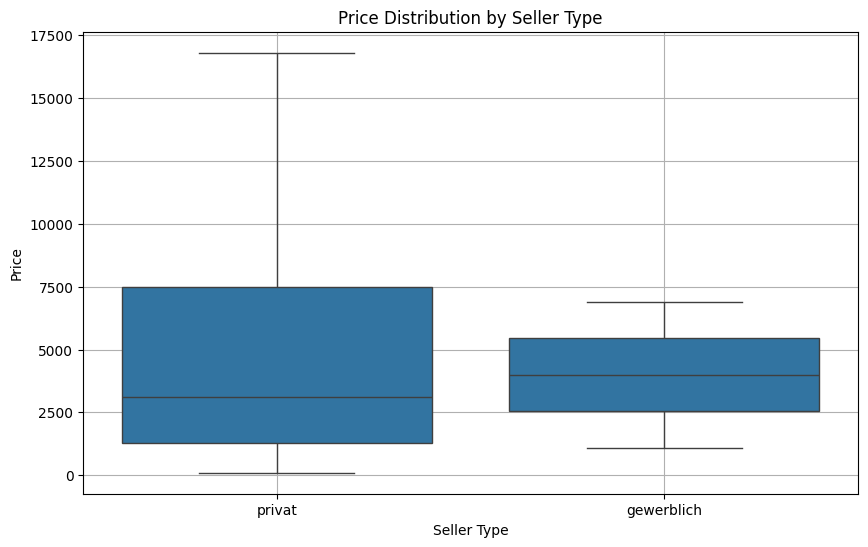


Advice for Customers:
- Use the summary and boxplot to identify if private sellers generally offer lower prices than dealers.
- Use location-based analysis to find areas with the most competitive prices.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm

# Load the dataset (Replace 'your_file_path.csv' with the actual file path)
data = pd.read_csv('/content/MRM.csv')



# Compare seller types (private vs dealer)
# Group data by seller type and calculate statistics
seller_summary = valid_data.groupby('seller')[['price']].describe()
print("Seller Type Summary:\n", seller_summary)

# Plot price distribution by seller type
plt.figure(figsize=(10, 6))
sns.boxplot(data=valid_data, x='seller', y='price', showfliers=False)
plt.title('Price Distribution by Seller Type')
plt.xlabel('Seller Type')
plt.ylabel('Price')
plt.grid(True)
plt.show()

# Analyze seller locations and price differences
if 'location' in valid_data.columns:
    location_summary = valid_data.groupby(['seller', 'location'])['price'].mean().unstack('seller')
    print("Location-based Price Summary:\n", location_summary.head())

    # Heatmap for location-based average prices by seller type
    plt.figure(figsize=(12, 8))
    sns.heatmap(location_summary, annot=False, cmap='coolwarm', cbar=True)
    plt.title('Average Prices by Seller Type and Location')
    plt.xlabel('Seller Type')
    plt.ylabel('Location')
    plt.show()

# Advice on seller types
print("\nAdvice for Customers:")
print("- Use the summary and boxplot to identify if private sellers generally offer lower prices than dealers.")
print("- Use location-based analysis to find areas with the most competitive prices.")


Seller Type Summary:
                price                                                     \
               count          mean           std    min     25%     50%   
seller                                                                    
gewerblich       3.0   2700.000000  3.671512e+03  100.0   600.0  1100.0   
privat      371524.0  17295.295504  3.587973e+06    0.0  1150.0  2950.0   

                                  
               75%           max  
seller                            
gewerblich  4000.0  6.900000e+03  
privat      7200.0  2.147484e+09  


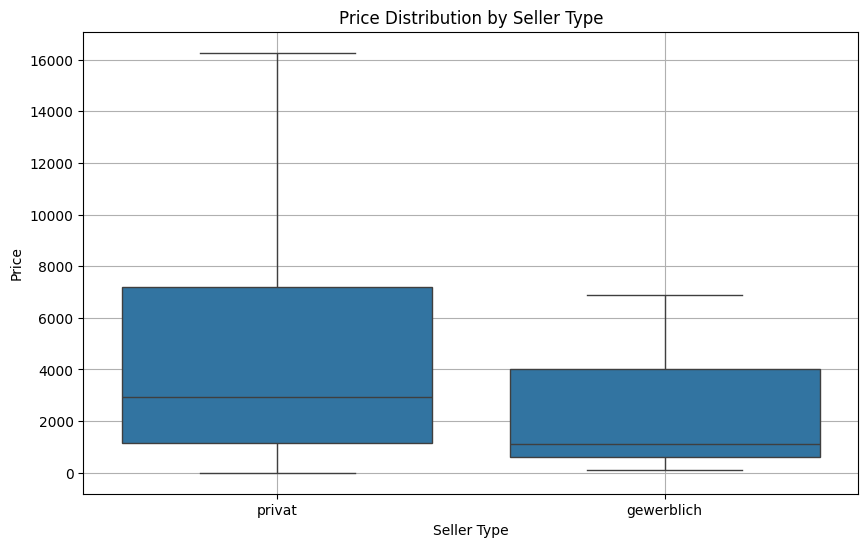

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm

# Load the dataset (Replace 'your_file_path.csv' with the actual file path)
data = pd.read_csv('/content/MRM.csv')

# Compare seller types (private vs dealer)
# Group data by seller type and calculate statistics
seller_summary = data.groupby('seller')[['price']].describe()
print("Seller Type Summary:\n", seller_summary)

# Plot price distribution by seller type
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='seller', y='price', showfliers=False)
plt.title('Price Distribution by Seller Type')
plt.xlabel('Seller Type')
plt.ylabel('Price')
plt.grid(True)
plt.show()

# Analyze seller locations and price differences
if 'location' in data.columns:
    location_summary = data.groupby(['seller', 'location'])['price'].mean().unstack('seller')
    print("Location-based Price Summary:\n", location_summary.head())

    # Heatmap for location-based average prices by seller type
    plt.figure(figsize=(12, 8))
    sns.heatmap(location_summary, annot=False, cmap='coolwarm', cbar=True)
    plt.title('Average Prices by Seller Type and Location')
    plt.xlabel('Seller Type')
    plt.ylabel('Location')
    plt.show()


In [ ]:
import pandas as pd

# Load the dataset (Replace 'your_file_path.csv' with the actual file path)
data = pd.read_csv('/content/MRM.csv')

# Calculate correlation between price and powerPS (Engine Power)
correlation_price_powerPS = data['price'].corr(data['powerPS'])
print(f"Correlation between price and powerPS (Engine Power): {correlation_price_powerPS:.4f}")

# Generate descriptive statistics for all fields in the dataset
descriptive_statistics = data.describe(include='all')

# Display the summary of descriptive statistics
print("\nDescriptive Statistics Summary:")
print(descriptive_statistics)



Correlation between price and powerPS (Engine Power): 0.0069

Descriptive Statistics Summary:
                index     dateCrawled         name  seller offerType  \
count   371527.000000          371527       371527  371527    371527   
unique            NaN           15622       233519       2         2   
top               NaN  05/03/16 14:25  Ford_Fiesta  privat   Angebot   
freq              NaN              68          657  371524    371515   
mean    185763.617161             NaN          NaN     NaN       NaN   
std     107251.160306             NaN          NaN     NaN       NaN   
min          0.000000             NaN          NaN     NaN       NaN   
25%      92881.500000             NaN          NaN     NaN       NaN   
50%     185764.000000             NaN          NaN     NaN       NaN   
75%     278645.500000             NaN          NaN     NaN       NaN   
max     371527.000000             NaN          NaN     NaN       NaN   

       vehicleType  yearOfRegistration  g